# NOTEBOOK PREPROCESSING: Slum Detection

**Notebook ini terdiri dari 2 bagian:**

- **PART A**: Preprocessing FDL Slums Dataset (Mumbai + Nairobi 3 sub-kota) -> dipakai Phase 1
- **PART B**: Preprocessing Indonesia (DKI Jakarta GeoJSON + Sentinel-2 tiles) -> dipakai Phase 2
- **PART C**: Compute stats per-source + final summary

---


## 1. Setup & Imports

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize           
from rasterio.warp import transform_geom        
import geopandas as gpd                         
from shapely.geometry import box, mapping
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.ndimage import zoom as nd_zoom         

warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 50)

SEED = 42
np.random.seed(SEED)

print("Library loaded:")
print(f"  numpy     : {np.__version__}")
print(f"  pandas    : {pd.__version__}")
print(f"  rasterio  : {rasterio.__version__}")
print(f"  geopandas : {gpd.__version__}")

e:\competition\Datathon\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Library loaded:
  numpy     : 1.26.4
  pandas    : 2.3.3
  rasterio  : 1.4.4
  geopandas : 1.1.3


---
## 2. Path Configuration


In [2]:
# === Path utama ===
ROOT      = Path(r"E:\competition\Datathon")
DATA_DIR  = ROOT / "dataset"
PROC_DIR  = ROOT / "processed"
PATCHES_DIR = PROC_DIR / "patches"
FIG_DIR     = PROC_DIR / "figures"

for d in [PROC_DIR, PATCHES_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Sub-paths raw (Sentinel-2 only, skip DG drone) ===
MUMBAI_DIRS = [
    DATA_DIR / "India" / "Mumbai" / "S2" / "training",
]

NAIROBI_DIRS = [
    DATA_DIR / "Nairobi" / "Kianda" / "S2" / "training",
    DATA_DIR / "Nairobi" / "Kibera" / "S2" / "training",
    DATA_DIR / "Nairobi" / "Lower"  / "S2" / "training",
]

# === Indonesia (DKI Jakarta) - dipakai PART B ===
INDONESIA_DIR        = DATA_DIR / "Indonesia"
INDONESIA_IMG_SLUM   = INDONESIA_DIR / "images" / "slum"
INDONESIA_IMG_NONSL  = INDONESIA_DIR / "images" / "non_slum"
INDONESIA_LBL_SLUM   = INDONESIA_DIR / "labels" / "dki_slum.geojson"
INDONESIA_LBL_NONSL  = INDONESIA_DIR / "labels" / "dki_non_slum.geojson"

print("Direktori utama:")
print(f"  ROOT        : {ROOT}")
print(f"  DATA_DIR    : {DATA_DIR}  (exists: {DATA_DIR.exists()})")
print(f"  PROC_DIR    : {PROC_DIR}")
print(f"  PATCHES_DIR : {PATCHES_DIR}")

print(f"\nMumbai sub-dirs ({len(MUMBAI_DIRS)}):")
for d in MUMBAI_DIRS:
    print(f"  - {d}  [exists: {d.exists()}]")

print(f"\nNairobi sub-dirs ({len(NAIROBI_DIRS)}):")
for d in NAIROBI_DIRS:
    print(f"  - {d}  [exists: {d.exists()}]")

print(f"\nIndonesia (DKI Jakarta):")
print(f"  images/slum     : {INDONESIA_IMG_SLUM}    [exists: {INDONESIA_IMG_SLUM.exists()}]")
print(f"  images/non_slum : {INDONESIA_IMG_NONSL}   [exists: {INDONESIA_IMG_NONSL.exists()}]")
print(f"  label slum      : {INDONESIA_LBL_SLUM}    [exists: {INDONESIA_LBL_SLUM.exists()}]")
print(f"  label non_slum  : {INDONESIA_LBL_NONSL}   [exists: {INDONESIA_LBL_NONSL.exists()}]")

Direktori utama:
  ROOT        : E:\competition\Datathon
  DATA_DIR    : E:\competition\Datathon\dataset  (exists: True)
  PROC_DIR    : E:\competition\Datathon\processed
  PATCHES_DIR : E:\competition\Datathon\processed\patches

Mumbai sub-dirs (1):
  - E:\competition\Datathon\dataset\India\Mumbai\S2\training  [exists: True]

Nairobi sub-dirs (3):
  - E:\competition\Datathon\dataset\Nairobi\Kianda\S2\training  [exists: True]
  - E:\competition\Datathon\dataset\Nairobi\Kibera\S2\training  [exists: True]
  - E:\competition\Datathon\dataset\Nairobi\Lower\S2\training  [exists: True]

Indonesia (DKI Jakarta):
  images/slum     : E:\competition\Datathon\dataset\Indonesia\images\slum    [exists: True]
  images/non_slum : E:\competition\Datathon\dataset\Indonesia\images\non_slum   [exists: True]
  label slum      : E:\competition\Datathon\dataset\Indonesia\labels\dki_slum.geojson    [exists: True]
  label non_slum  : E:\competition\Datathon\dataset\Indonesia\labels\dki_non_slum.geojson   [exi

---
## 3. Inventory Dataset


In [3]:
def inventory_fdl(folders, source_name):
    """Scan list of S2/training folders untuk pasangan image + ground truth."""
    if not isinstance(folders, (list, tuple)):
        folders = [folders]

    rows = []
    for folder in folders:
        folder = Path(folder)
        if not folder.exists():
            print(f"[{source_name}] folder tidak ada, skip: {folder}")
            continue

        # Image utama = .tif yang BUKAN ground_truth/label/mask
        images = sorted([
            p for p in folder.glob("*.tif")
            if "ground_truth" not in p.stem.lower()
            and "label"        not in p.stem.lower()
            and "mask"         not in p.stem.lower()
        ])

        for img in images:
            label_candidates = [
                img.parent / f"{img.stem}_ground_truth.tif",
                img.parent / f"{img.stem}_label.tif",
                img.parent / f"{img.stem}_mask.tif",
            ]
            label = next((c for c in label_candidates if c.exists()), None)

            # Area = nama folder 3 level di atas file (contoh: Mumbai, Kianda, Kibera, Lower)
            # struktur: .../{AREA}/S2/training/{file}.tif
            area = img.parent.parent.parent.name

            rows.append({
                "source"    : source_name,
                "area"      : area,
                "image_path": str(img),
                "label_path": str(label) if label else None,
                "size_mb"   : img.stat().st_size / 1e6,
                "has_label" : label is not None,
            })

    return pd.DataFrame(rows)


inv_mumbai  = inventory_fdl(MUMBAI_DIRS,  "mumbai")
inv_nairobi = inventory_fdl(NAIROBI_DIRS, "nairobi")
inv_all     = pd.concat([inv_mumbai, inv_nairobi], ignore_index=True)

print("=== Inventory Summary ===")
print(inv_all.groupby(["source","area"]).agg(
    n_tiles =("image_path", "count"),
    n_label =("has_label",  "sum"),
    size_MB =("size_mb",    "sum")
).round(2))

print(f"\nTotal tile dengan label valid: {inv_all['has_label'].sum()} / {len(inv_all)}")

if inv_all["has_label"].sum() == 0:
    raise FileNotFoundError(
        "Tidak ada pasangan image-label valid yang ditemukan. "
        "Cek struktur folder dan pastikan file *.tif + *_ground_truth.tif ada."
    )

=== Inventory Summary ===
                n_tiles  n_label  size_MB
source  area                             
mumbai  Mumbai        1        1   118.69
nairobi Kianda        1        1     0.06
        Kibera        1        1     0.60
        Lower         1        1     1.04

Total tile dengan label valid: 4 / 4


---
## 4. Inspect Tile Metadata

In [4]:
def inspect_tile(image_path, label_path=None):
    info = {}
    with rasterio.open(image_path) as src:
        info["image_shape"]  = (src.count, src.height, src.width)
        info["image_dtype"]  = str(src.dtypes[0])
        info["image_crs"]    = str(src.crs)
        info["image_nodata"] = src.nodata
        info["image_bounds"] = tuple(round(v, 2) for v in src.bounds)
    if label_path and Path(label_path).exists():
        with rasterio.open(label_path) as src:
            info["label_shape"]  = (src.count, src.height, src.width)
            info["label_dtype"]  = str(src.dtypes[0])
            info["label_crs"]    = str(src.crs)
    return info


print("=== Metadata setiap tile ===\n")
for _, row in inv_all.iterrows():
    info = inspect_tile(row["image_path"], row["label_path"])
    print(f"[{row['source']:>7s} / {row['area']:>10s}] {Path(row['image_path']).name}")
    print(f"  Image : shape={info['image_shape']}, dtype={info['image_dtype']}, "
          f"CRS={info['image_crs']}, nodata={info['image_nodata']}")
    if "label_shape" in info:
        match_str = "OK" if info['label_shape'][1:] == info['image_shape'][1:] else "MISMATCH"
        print(f"  Label : shape={info['label_shape']}, dtype={info['label_dtype']}  "
              f"[image-label shape: {match_str}]")
    print()

=== Metadata setiap tile ===

[ mumbai /     Mumbai] Mumbai.tif
  Image : shape=(10, 3927, 1993), dtype=float32, CRS=EPSG:32643, nodata=None
  Label : shape=(1, 3927, 1993), dtype=uint8  [image-label shape: OK]

[nairobi /     Kianda] Kianda.tif
  Image : shape=(10, 42, 34), dtype=float32, CRS=EPSG:32737, nodata=None
  Label : shape=(1, 42, 34), dtype=uint8  [image-label shape: OK]

[nairobi /     Kibera] Kibera.tif
  Image : shape=(10, 118, 256), dtype=float32, CRS=EPSG:32737, nodata=None
  Label : shape=(1, 118, 256), dtype=int16  [image-label shape: OK]

[nairobi /      Lower] Lower.tif
  Image : shape=(10, 46, 567), dtype=float32, CRS=EPSG:32737, nodata=None
  Label : shape=(1, 46, 567), dtype=uint8  [image-label shape: OK]



---
## 5. EDA Raw - RGB Visualization per Area


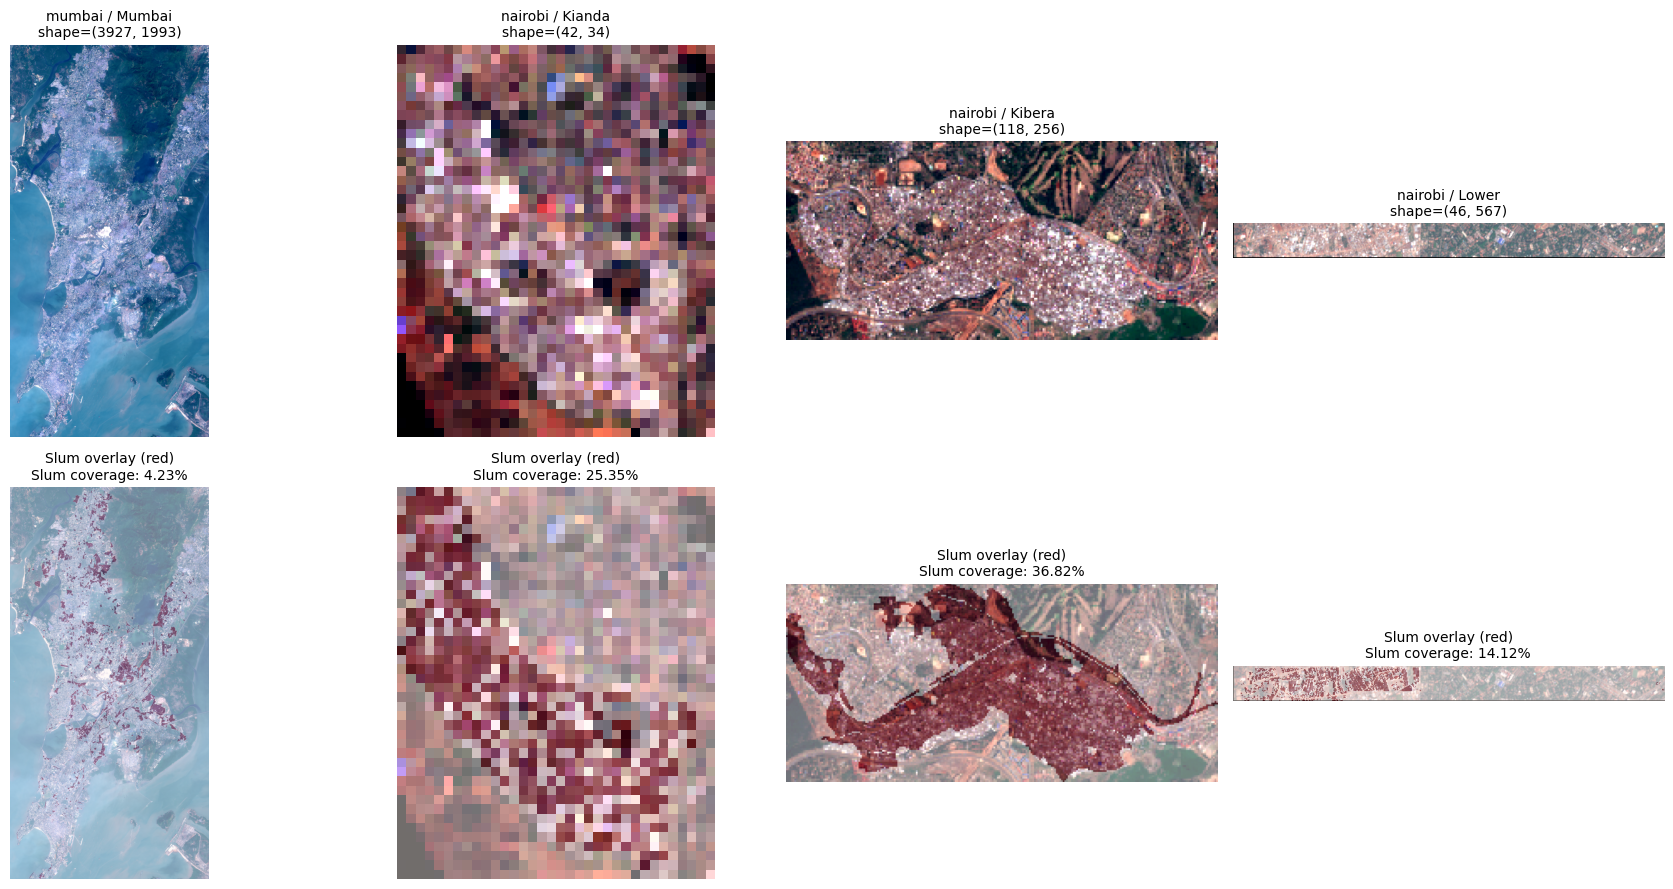


Ditampilkan 4 area: [{'source': 'mumbai', 'area': 'Mumbai'}, {'source': 'nairobi', 'area': 'Kianda'}, {'source': 'nairobi', 'area': 'Kibera'}, {'source': 'nairobi', 'area': 'Lower'}]


In [5]:
def load_rgb_fdl(image_path):
    """Load RGB composite dari FDL 10-band: B2(BLUE)=idx0, B3(GREEN)=idx1, B4(RED)=idx2.

    Untuk Sentinel-2 10-band order standar: [B1, B2, B3, B4, B5, B6, B7, B8, B11, B12]
    Maka RGB = (B4, B3, B2) = (idx 3, 2, 1) di rasterio (1-indexed).
    """
    with rasterio.open(image_path) as src:
        rgb = src.read([3, 2, 1]).astype(np.float32)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
    return rgb.transpose(1, 2, 0)


def load_label_tif(label_path):
    if label_path is None or not Path(label_path).exists():
        return None
    with rasterio.open(label_path) as src:
        return (src.read(1) > 0).astype(np.uint8)


# Grid dinamis: 2 baris (RGB / overlay) x N kolom (per area)
labeled = inv_all[inv_all["has_label"]].reset_index(drop=True)
n_show  = len(labeled)

fig, axes = plt.subplots(2, n_show, figsize=(4.5 * n_show, 9), squeeze=False)

for i, row in labeled.iterrows():
    rgb   = load_rgb_fdl(row["image_path"])
    label = load_label_tif(row["label_path"])

    axes[0, i].imshow(rgb)
    axes[0, i].axis("off")
    axes[0, i].set_title(
        f"{row['source']} / {row['area']}\n"
        f"shape={rgb.shape[:2]}",
        fontsize=10
    )

    slum_pct = label.mean() * 100
    axes[1, i].imshow(rgb)
    axes[1, i].imshow(label, alpha=0.45, cmap="Reds")
    axes[1, i].axis("off")
    axes[1, i].set_title(
        f"Slum overlay (red)\n"
        f"Slum coverage: {slum_pct:.2f}%",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "s5_raw_rgb_overlay.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"\nDitampilkan {n_show} area: {labeled[['source','area']].to_dict('records')}")

---
## 6. EDA Raw - Slum Coverage per Tile

**WHAT:** Hitung persentase pixel slum di tiap tile mentah.

**WHY:** Insight awal class imbalance. Kalau slum coverage:
- **<1%** -> ekstrim imbalance, kita perlu strategi sampling khusus + class weight tinggi.
- **5-15%** -> moderate imbalance, class weight cukup.
- **>30%** -> hampir balanced, tidak perlu treatment khusus.

Hasil ini akan menentukan setting `CE_WEIGHT_SLUM` di Phase 1 (default 2.0).


=== Slum Coverage per Tile ===
 source   area  n_pixel  n_slum_px  slum_pct
 mumbai Mumbai  7826511     330673  4.225037
nairobi Kianda     1428        362 25.350140
nairobi Kibera    30208      11124 36.824682
nairobi  Lower    26082       3684 14.124684

Mean slum coverage all tiles: 20.13%
Min : 4.23%  (Mumbai)
Max : 36.82%  (Kibera)


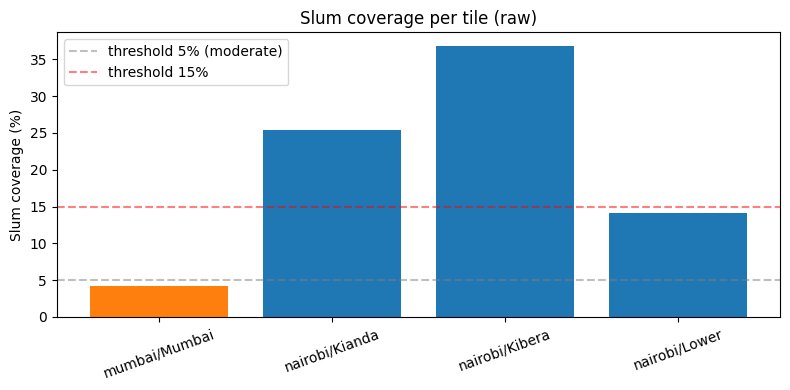

In [6]:
coverage_rows = []
for _, row in inv_all.iterrows():
    if not row["has_label"]:
        continue
    lbl = load_label_tif(row["label_path"])
    coverage_rows.append({
        "source"     : row["source"],
        "area"       : row["area"],
        "n_pixel"    : int(lbl.size),
        "n_slum_px"  : int(lbl.sum()),
        "slum_pct"   : 100.0 * lbl.mean(),
    })

cov_df = pd.DataFrame(coverage_rows)
print("=== Slum Coverage per Tile ===")
print(cov_df.to_string(index=False))

print(f"\nMean slum coverage all tiles: {cov_df['slum_pct'].mean():.2f}%")
print(f"Min : {cov_df['slum_pct'].min():.2f}%  ({cov_df.loc[cov_df['slum_pct'].idxmin(), 'area']})")
print(f"Max : {cov_df['slum_pct'].max():.2f}%  ({cov_df.loc[cov_df['slum_pct'].idxmax(), 'area']})")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#ff7f0e" if s == "mumbai" else "#1f77b4" for s in cov_df["source"]]
ax.bar(cov_df["source"] + "/" + cov_df["area"], cov_df["slum_pct"], color=colors)
ax.set_ylabel("Slum coverage (%)")
ax.set_title("Slum coverage per tile (raw)")
ax.axhline(5,  ls="--", color="gray", alpha=0.5, label="threshold 5% (moderate)")
ax.axhline(15, ls="--", color="red",  alpha=0.5, label="threshold 15%")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "s6_slum_coverage.png", bbox_inches="tight", dpi=120)
plt.show()

---
## 7. Hyperparameter Patch Extraction

In [ ]:
# === Hyperparameter patch extraction ===
PATCH_SIZE      = 224
STRIDE          = 112     
NODATA_FRAC_MAX = 0.50
STD_MIN         = 1e-6

print(f"Patch size      : {PATCH_SIZE} x {PATCH_SIZE}")
print(f"Stride          : {STRIDE} (overlap = {(1 - STRIDE/PATCH_SIZE)*100:.0f}%)")
print(f"Nodata threshold: drop kalau >{NODATA_FRAC_MAX*100:.0f}% pixel zero")
print(f"Std threshold   : drop kalau std < {STD_MIN}")

# Estimasi jumlah patch sebelum filter (dengan adaptive mode)
# Mode logic:
#   - Tile >= PATCH_SIZE di kedua dim: sliding window normal
#   - Tile salah satu dim < MIN_FOR_PAD: resize ke 224x224 -> 1 patch
#   - Tile salah satu dim antara MIN_FOR_PAD..PATCH_SIZE: pad reflect ke 224 + slide
MIN_FOR_PAD = 100   # threshold: di bawah ini pakai resize, di atas pakai pad

print(f"\n=== Estimasi jumlah patch per tile (adaptive mode) ===")
total_est = 0
for _, row in inv_all.iterrows():
    if not row["has_label"]:
        continue
    with rasterio.open(row["image_path"]) as src:
        H, W = src.height, src.width

    if H >= PATCH_SIZE and W >= PATCH_SIZE:
        n_y = max(0, (H - PATCH_SIZE) // STRIDE + 1)
        n_x = max(0, (W - PATCH_SIZE) // STRIDE + 1)
        n_patch = n_y * n_x
        mode = "sliding"
    elif H < MIN_FOR_PAD or W < MIN_FOR_PAD:
        n_patch = 1
        mode = "resize"
    else:
        H_eff = max(H, PATCH_SIZE)
        W_eff = max(W, PATCH_SIZE)
        n_y = max(1, (H_eff - PATCH_SIZE) // STRIDE + 1)
        n_x = max(1, (W_eff - PATCH_SIZE) // STRIDE + 1)
        n_patch = n_y * n_x
        mode = "pad+slide"

    total_est += n_patch
    print(f"  [{row['source']}/{row['area']:>10s}] {H}x{W} -> [{mode:>10s}] = {n_patch} patches")

print(f"\nTotal estimasi (sebelum filter): {total_est} patches")
print(f"Estimasi setelah filter (~70% lolos untuk sliding): bervariasi")

Patch size      : 224 x 224
Stride          : 112 (overlap = 50%)
Nodata threshold: drop kalau >50% pixel zero
Std threshold   : drop kalau std < 1e-06

=== Estimasi jumlah patch per tile (adaptive mode) ===
  [mumbai/    Mumbai] 3927x1993 -> [   sliding] = 544 patches
  [nairobi/    Kianda] 42x34 -> [    resize] = 1 patches
  [nairobi/    Kibera] 118x256 -> [ pad+slide] = 1 patches
  [nairobi/     Lower] 46x567 -> [    resize] = 1 patches

Total estimasi (sebelum filter): 547 patches
Estimasi setelah filter (~70% lolos untuk sliding): bervariasi


---
## 8. Band Mapping FDL 10-band -> Prithvi 6-band

**WHAT:** Pilih 6 band Sentinel-2 yang dipakai Prithvi-EO-2.0 dari 10 band FDL.

**WHY:**
Prithvi-EO-2.0 di-pretrain pada **6 band spesifik** (BLUE, GREEN, RED, NIR, SWIR1, SWIR2). Jika kita feed model dengan band lain (atau urutan salah), pre-trained weights tidak akan match dengan input distribution -> performa drop drastis.

**Mapping FDL Sentinel-2 10-band standard:**

| Index FDL | Band Sentinel-2 | Wavelength | Nama |
|-----------|----------------|------------|------|
| 0 | B1 | 443 nm | Coastal aerosol |
| 1 | B2 | 490 nm | **BLUE** (pakai) |
| 2 | B3 | 560 nm | **GREEN** (pakai) |
| 3 | B4 | 665 nm | **RED** (pakai) |
| 4 | B5 | 705 nm | Vegetation Red Edge 1 |
| 5 | B6 | 740 nm | Vegetation Red Edge 2 |
| 6 | B7 | 783 nm | Vegetation Red Edge 3 |
| 7 | B8 | 842 nm | **NIR** (pakai) |
| 8 | B11 | 1610 nm | **SWIR1** (pakai) |
| 9 | B12 | 2190 nm | **SWIR2** (pakai) |

Index yang dipakai: `[1, 2, 3, 7, 8, 9]`.

> **CATATAN:** Beberapa versi FDL Slums Dataset menyimpan 10 band tanpa B1 (mulai dari B2). Cek output Section 4: kalau `image_shape[0] == 10`, kita asumsi pattern di atas. Kalau hasil RGB di Section 5 terlihat aneh, mapping mungkin perlu di-shift.


In [8]:
# Index 6 band Sentinel-2 yang dipakai Prithvi-EO-2.0
PRITHVI_BAND_NAMES = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]

# Mapping FDL 10-band [B1,B2,B3,B4,B5,B6,B7,B8,B11,B12] -> Prithvi 6-band
PRITHVI_BAND_IDX_FROM_FDL_10 = [1, 2, 3, 7, 8, 9]

# Auto-detect band count dari tile pertama
with rasterio.open(inv_all[inv_all["has_label"]].iloc[0]["image_path"]) as src:
    n_bands_detected = src.count

print(f"Band count terdeteksi : {n_bands_detected}")
if n_bands_detected == 10:
    BAND_IDX = PRITHVI_BAND_IDX_FROM_FDL_10
    print(f"Mapping aktif         : FDL 10-band -> Prithvi 6-band")
    print(f"Index yang dipilih    : {BAND_IDX}")
elif n_bands_detected == 6:
    BAND_IDX = [0, 1, 2, 3, 4, 5]
    print(f"Mapping aktif         : Direct 6-band (sudah pre-selected)")
elif n_bands_detected == 13:
    # Sentinel-2 L2A full 13-band: [B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,B12]
    BAND_IDX = [1, 2, 3, 7, 11, 12]
    print(f"Mapping aktif         : Sentinel-2 L2A 13-band -> Prithvi 6-band")
    print(f"Index yang dipilih    : {BAND_IDX}")
else:
    raise ValueError(
        f"Band count {n_bands_detected} tidak dikenali. "
        f"Beri tahu agen untuk re-mapping band."
    )

print(f"\n6 band yang dipakai  : {PRITHVI_BAND_NAMES}")

Band count terdeteksi : 10
Mapping aktif         : FDL 10-band -> Prithvi 6-band
Index yang dipilih    : [1, 2, 3, 7, 8, 9]

6 band yang dipakai  : ['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR1', 'SWIR2']


---
## 9. Patch Extraction Function


In [ ]:
from scipy.ndimage import zoom as nd_zoom


def adapt_to_min_size(img, lbl, patch_size=PATCH_SIZE, min_for_pad=MIN_FOR_PAD):
    """Adaptive: kalau tile lebih kecil dari patch_size, lakukan resize ATAU pad.

    Returns: (img_out, lbl_out, mode_str)
        - img_out: float32 (C, H', W') dgn H',W' >= patch_size
        - lbl_out: uint8   (H', W')
        - mode_str: 'sliding' | 'pad' | 'resize'
    """
    H, W = img.shape[1], img.shape[2]

    # Mode 1: tile cukup besar, sliding window normal
    if H >= patch_size and W >= patch_size:
        return img, lbl, "sliding"

    # Mode 2: salah satu dim < MIN_FOR_PAD, resize ke patch_size x patch_size
    if H < min_for_pad or W < min_for_pad:
        scale_h = patch_size / H
        scale_w = patch_size / W
        # Bilinear (order=1) untuk image, nearest (order=0) untuk label
        img_resized = nd_zoom(img, (1.0, scale_h, scale_w), order=1, prefilter=False).astype(np.float32)
        lbl_resized = nd_zoom(lbl, (scale_h, scale_w),       order=0, prefilter=False).astype(np.uint8)
        # Crop/clamp ke ukuran tepat (zoom kadang off by 1)
        img_resized = img_resized[:, :patch_size, :patch_size]
        lbl_resized = lbl_resized[:patch_size, :patch_size]
        # Pad kalau short (defensive)
        if img_resized.shape[1] < patch_size or img_resized.shape[2] < patch_size:
            ph = patch_size - img_resized.shape[1]
            pw = patch_size - img_resized.shape[2]
            img_resized = np.pad(img_resized, ((0,0),(0,ph),(0,pw)), mode="edge")
            lbl_resized = np.pad(lbl_resized, ((0,ph),(0,pw)),       mode="constant", constant_values=0)
        return img_resized, lbl_resized, "resize"

    # Mode 3: pad dim yang < patch_size dengan reflect (image) + zero (label)
    pad_h = max(0, patch_size - H)
    pad_w = max(0, patch_size - W)
    pad_top, pad_bot = pad_h // 2, pad_h - pad_h // 2
    pad_lef, pad_rig = pad_w // 2, pad_w - pad_w // 2
    img_padded = np.pad(img, ((0,0),(pad_top, pad_bot),(pad_lef, pad_rig)), mode="reflect")
    # Label di-pad dengan 0 (jangan reflect, label tidak boleh fake-positive)
    lbl_padded = np.pad(lbl, ((pad_top, pad_bot),(pad_lef, pad_rig)),       mode="constant", constant_values=0)
    return img_padded, lbl_padded, "pad"


def extract_patches_from_tile(image_path, label_path, source, area,
                               band_idx=None, patch_size=PATCH_SIZE, stride=STRIDE):
    """Tile image + label -> daftar patch 224x224 valid, save sebagai .npz.

    Adaptive untuk tile kecil:
      - >= 224 di kedua dim  -> sliding window
      - salah satu dim < 100 -> resize ke 224x224 (1 patch)
      - dim 100..223         -> reflect-pad image + zero-pad label, lalu slide
    """
    if band_idx is None:
        band_idx = BAND_IDX

    with rasterio.open(image_path) as src_img:
        rio_indexes = [b + 1 for b in band_idx]
        img = src_img.read(rio_indexes).astype(np.float32)   

    with rasterio.open(label_path) as src_lbl:
        lbl = (src_lbl.read(1) > 0).astype(np.uint8)      

    # Crop kalau shape image vs label beda
    H_img, W_img = img.shape[1], img.shape[2]
    H_lbl, W_lbl = lbl.shape
    H, W = min(H_img, H_lbl), min(W_img, W_lbl)
    img = img[:, :H, :W]
    lbl = lbl[:H, :W]

    # Adaptive: kalau tile kecil, resize/pad dulu
    img, lbl, mode = adapt_to_min_size(img, lbl, patch_size=patch_size,
                                        min_for_pad=MIN_FOR_PAD)
    H, W = img.shape[1], img.shape[2]

    patches_info = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            img_patch = img[:, y:y+patch_size, x:x+patch_size]
            lbl_patch = lbl[y:y+patch_size, x:x+patch_size]

            # === Quality filters ===
            zero_frac = float((img_patch == 0).all(axis=0).mean())
            if zero_frac > NODATA_FRAC_MAX:
                continue
            if not np.isfinite(img_patch).all():
                continue
            if img_patch.std() < STD_MIN:
                continue

            slum_ratio = float(lbl_patch.mean())

            patch_id   = f"{source}__{area}__y{y}_x{x}"
            patch_file = PATCHES_DIR / f"{patch_id}.npz"
            np.savez_compressed(
                patch_file,
                image=img_patch.astype(np.float32),
                label=lbl_patch.astype(np.uint8)
            )

            patches_info.append({
                "patch_id"        : patch_id,
                "source"          : source,
                "area"            : area,
                "image_relpath"   : f"patches/{patch_id}.npz",
                "label_relpath"   : f"patches/{patch_id}.npz",
                "x_coord"         : int(x),
                "y_coord"         : int(y),
                "slum_pixel_ratio": round(slum_ratio, 6),
                "extraction_mode" : mode,
            })

    # Edge case: kalau loop tidak generate patch sama sekali (misal mode='resize'
    # tapi quality filter drop), generate 1 patch tanpa filter (last resort).
    if len(patches_info) == 0 and (mode == "resize" or mode == "pad"):
        img_patch = img[:, :patch_size, :patch_size]
        lbl_patch = lbl[:patch_size, :patch_size]
        if np.isfinite(img_patch).all() and img_patch.std() >= STD_MIN:
            slum_ratio = float(lbl_patch.mean())
            patch_id   = f"{source}__{area}__y0_x0_{mode}"
            patch_file = PATCHES_DIR / f"{patch_id}.npz"
            np.savez_compressed(patch_file,
                                image=img_patch.astype(np.float32),
                                label=lbl_patch.astype(np.uint8))
            patches_info.append({
                "patch_id"        : patch_id,
                "source"          : source,
                "area"            : area,
                "image_relpath"   : f"patches/{patch_id}.npz",
                "label_relpath"   : f"patches/{patch_id}.npz",
                "x_coord"         : 0,
                "y_coord"         : 0,
                "slum_pixel_ratio": round(slum_ratio, 6),
                "extraction_mode" : mode,
            })

    return patches_info


print("Function extract_patches_from_tile siap dipakai (adaptive: sliding/pad/resize).")
print(f"Output patches akan disimpan di: {PATCHES_DIR}")

Function extract_patches_from_tile siap dipakai (adaptive: sliding/pad/resize).
Output patches akan disimpan di: E:\competition\Datathon\processed\patches


---
## 10. Run Patch Extraction

In [10]:
# Hapus dulu file lama supaya tidak ada kontaminasi
for old_npz in PATCHES_DIR.glob("*.npz"):
    old_npz.unlink()
print(f"Dihapus file lama di {PATCHES_DIR}\n")

all_patches = []
labeled_tiles = inv_all[inv_all["has_label"]].reset_index(drop=True)

for _, row in tqdm(labeled_tiles.iterrows(), total=len(labeled_tiles),
                   desc="Extracting tiles"):
    p_info = extract_patches_from_tile(
        row["image_path"], row["label_path"],
        row["source"], row["area"]
    )
    all_patches.extend(p_info)
    print(f"  [{row['source']}/{row['area']:>10s}] -> {len(p_info)} patches valid")

manifest_full = pd.DataFrame(all_patches)
manifest_full.to_csv(PROC_DIR / "manifest.csv", index=False)

print(f"\n=== Extraction Selesai ===")
print(f"Total patches valid : {len(manifest_full)}")
print(f"Manifest disimpan   : {PROC_DIR / 'manifest.csv'}")
print(f"Patches disimpan    : {PATCHES_DIR}")
print(f"Disk usage patches  : {sum(f.stat().st_size for f in PATCHES_DIR.glob('*.npz'))/1e6:.1f} MB")

Dihapus file lama di E:\competition\Datathon\processed\patches



Extracting tiles:  75%|███████▌  | 3/4 [00:42<00:11, 11.04s/it]

  [mumbai/    Mumbai] -> 544 patches valid
  [nairobi/    Kianda] -> 1 patches valid
  [nairobi/    Kibera] -> 1 patches valid


Extracting tiles: 100%|██████████| 4/4 [00:42<00:00, 10.64s/it]

  [nairobi/     Lower] -> 1 patches valid

=== Extraction Selesai ===
Total patches valid : 547
Manifest disimpan   : E:\competition\Datathon\processed\manifest.csv
Patches disimpan    : E:\competition\Datathon\processed\patches
Disk usage patches  : 143.5 MB


---
## 11. Verifikasi Manifest

In [ ]:
manifest = pd.read_csv(PROC_DIR / "manifest.csv")
print(f"Manifest rows: {len(manifest)}")
print(f"Columns     : {list(manifest.columns)}")

# Check file existence
missing = []
for relpath in manifest["image_relpath"].head(50):  
    if not (PROC_DIR / relpath).exists():
        missing.append(relpath)
if missing:
    print(f"\n[WARNING] {len(missing)} file missing dari sample 50:")
    for m in missing[:5]:
        print(f"  - {m}")
else:
    print("\nFile check (sample 50): semua patch .npz ada di disk.")

# Distribusi per source/area
print(f"\n=== Distribusi Patches per Source/Area ===")
print(manifest.groupby(["source","area"]).agg(
    n_patches      =("patch_id", "count"),
    mean_slum_ratio=("slum_pixel_ratio", "mean"),
    n_pure_nonslum =("slum_pixel_ratio", lambda x: (x == 0).sum()),
    n_has_slum     =("slum_pixel_ratio", lambda x: (x > 0).sum()),
    n_pure_slum    =("slum_pixel_ratio", lambda x: (x >= 0.95).sum()),
).round(3))

print(f"\n=== Distribusi Slum Ratio Global ===")
print(manifest["slum_pixel_ratio"].describe().round(4))

# Audit: extraction_mode breakdown (sliding/pad/resize)
if "extraction_mode" in manifest.columns:
    print(f"\n=== Audit Extraction Mode (per source/area) ===")
    print(manifest.groupby(["source","area","extraction_mode"]).size().to_frame("n_patches"))
    n_resize = (manifest["extraction_mode"] == "resize").sum()
    n_pad    = (manifest["extraction_mode"] == "pad").sum()
    n_slide  = (manifest["extraction_mode"] == "sliding").sum()
    print(f"\n  sliding (optimal)        : {n_slide:>5d} patches")
    print(f"  pad     (border duplicate): {n_pad:>5d} patches")
    print(f"  resize  (lossy upscale)   : {n_resize:>5d} patches")
    if n_resize + n_pad > 0:
        print(f"\n  Catatan: patch pad/resize kualitasnya lebih rendah.")
        print(f"  Phase 1 boleh down-weight loss patch ini di Section 25 (Dataset class).")

Manifest rows: 547
Columns     : ['patch_id', 'source', 'area', 'image_relpath', 'label_relpath', 'x_coord', 'y_coord', 'slum_pixel_ratio', 'extraction_mode']

File check (sample 50): semua patch .npz ada di disk.

=== Distribusi Patches per Source/Area ===
                n_patches  mean_slum_ratio  n_pure_nonslum  n_has_slum  \
source  area                                                             
mumbai  Mumbai        544            0.048             203         341   
nairobi Kianda          1            0.261               0           1   
        Kibera          1            0.219               0           1   
        Lower           1            0.140               0           1   

                n_pure_slum  
source  area                 
mumbai  Mumbai            0  
nairobi Kianda            0  
        Kibera            0  
        Lower             0  

=== Distribusi Slum Ratio Global ===
count    547.0000
mean       0.0488
std        0.0710
min        0.0000
25%    

---
## 12. Compute Per-Source Statistics

**WHAT:** Hitung mean/std per band untuk setiap source (mumbai, nairobi). Simpan ke `stats.json`.

**WHY per-source (bukan global)?**
Mumbai dan Nairobi mungkin punya distribusi reflectance yang sedikit berbeda (vegetasi, atmosfer, tanggal akuisisi). Normalisasi per-source membuat model "sees" tiap dataset pada skala konsisten internal sambil tetap mempertahankan informasi relatif antar band.


In [12]:
print(f"Menghitung statistik per-source per-band...\n")
stats_dict = {}

for source, grp in manifest.groupby("source"):
    accum_sum = np.zeros(6, dtype=np.float64)
    accum_sq  = np.zeros(6, dtype=np.float64)
    accum_n   = 0

    for _, r in tqdm(grp.iterrows(), total=len(grp), desc=f"  [{source}]"):
        npz = np.load(PROC_DIR / r["image_relpath"])
        arr = npz["image"].astype(np.float64)            # (6, H, W)
        accum_sum += arr.sum(axis=(1, 2))
        accum_sq  += (arr ** 2).sum(axis=(1, 2))
        accum_n   += arr.shape[1] * arr.shape[2]

    mean = accum_sum / accum_n
    var  = accum_sq / accum_n - mean ** 2
    std  = np.sqrt(np.clip(var, 1e-12, None))

    stats_dict[source] = {
        "mean"      : mean.tolist(),
        "std"       : std.tolist(),
        "band_names": PRITHVI_BAND_NAMES,
        "n_pixels"  : int(accum_n),
        "n_patches" : int(len(grp)),
    }

    print(f"\n[{source}] (n_patches={len(grp)})")
    for i, b in enumerate(PRITHVI_BAND_NAMES):
        print(f"  {b:>6s}: mean={mean[i]:>10.2f}  std={std[i]:>10.2f}")

with open(PROC_DIR / "stats.json", "w") as f:
    json.dump(stats_dict, f, indent=2)

print(f"\nStats disimpan: {PROC_DIR / 'stats.json'}")

Menghitung statistik per-source per-band...



  [mumbai]: 100%|██████████| 544/544 [00:16<00:00, 34.00it/s]



[mumbai] (n_patches=544)
    BLUE: mean=   1065.65  std=    193.04
   GREEN: mean=    875.31  std=    281.80
     RED: mean=    921.50  std=    254.47
     NIR: mean=   1478.73  std=    807.61
   SWIR1: mean=    982.80  std=    659.44
   SWIR2: mean=    657.35  std=    523.82


  [nairobi]: 100%|██████████| 3/3 [00:00<00:00, 22.51it/s]


[nairobi] (n_patches=3)
    BLUE: mean=   1162.70  std=    239.53
   GREEN: mean=   1274.91  std=    313.83
     RED: mean=   1412.87  std=    224.05
     NIR: mean=   2106.16  std=    387.55
   SWIR1: mean=   2218.75  std=    326.66
   SWIR2: mean=   1844.56  std=    437.82

Stats disimpan: E:\competition\Datathon\processed\stats.json


**Interpretasi statistik:**

- Kalau `mean` di range **0-1** -> data sudah di-scale ke reflectance (float TOA).
- Kalau `mean` di range **0-10000** -> data masih DN (Digital Number) Sentinel-2 raw -> normalisasi ke z-score di model akan tetap work.
- `std` per band yang **mirip antar source** menunjukkan dataset well-curated. `std` yang sangat berbeda menunjukkan domain shift -> argumen kuat untuk per-source normalization.

**Bandingkan Mumbai vs Nairobi:**
- Mean RED Mumbai vs Nairobi: kalau beda <20% -> mirip.
- Mean NIR (vegetasi): biasanya Nairobi > Mumbai (Nairobi lebih hijau).
- Mean SWIR (built-up): biasanya Mumbai > Nairobi (Mumbai lebih dense urban).


---
## 13. EDA Post - Distribusi Slum Ratio

**WHAT:** Visualisasi distribusi `slum_pixel_ratio` per patch. Class balance check.

**WHY:** Menentukan strategi loss/sampling di Phase 1:
- Banyak patch slum_ratio = 0 (full non-slum) -> butuh class weight tinggi.
- Banyak patch slum_ratio mid-range (0.1-0.5) -> patch mixed, baik untuk segmentation learning.
- Sedikit patch pure slum -> jangan over-rely pada classification-style loss.


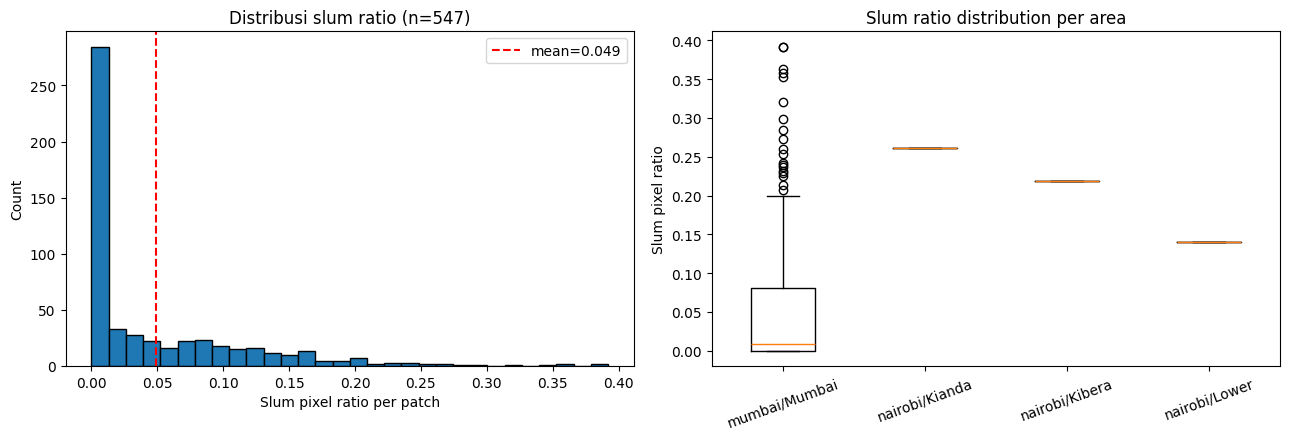


=== Class Balance Summary ===
Total patches  : 547
Total pixels   : 27,446,272
Slum pixels    : 1,338,802  (4.88%)
Non-slum pixels: 26,107,469  (95.12%)

Rekomendasi class weight slum di Phase 1: 19.5x
(Default Phase 1 pakai weight = 2.0, sudah OK untuk imbalance moderate)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram global
axes[0].hist(manifest["slum_pixel_ratio"], bins=30, color="#1f77b4", edgecolor="black")
axes[0].set_xlabel("Slum pixel ratio per patch")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Distribusi slum ratio (n={len(manifest)})")
axes[0].axvline(manifest["slum_pixel_ratio"].mean(), color="red", ls="--",
                label=f"mean={manifest['slum_pixel_ratio'].mean():.3f}")
axes[0].legend()

# Right: per source/area
src_area = manifest["source"] + "/" + manifest["area"]
data_per = [manifest.loc[src_area == k, "slum_pixel_ratio"].values
            for k in sorted(src_area.unique())]
axes[1].boxplot(data_per, tick_labels=sorted(src_area.unique()))
axes[1].set_xticklabels(sorted(src_area.unique()), rotation=20)
axes[1].set_ylabel("Slum pixel ratio")
axes[1].set_title("Slum ratio distribution per area")

plt.tight_layout()
plt.savefig(FIG_DIR / "s13_slum_ratio_dist.png", bbox_inches="tight", dpi=120)
plt.show()

# Summary class balance
print("\n=== Class Balance Summary ===")
total_px      = manifest["slum_pixel_ratio"].count() * PATCH_SIZE * PATCH_SIZE
slum_px_total = (manifest["slum_pixel_ratio"] * PATCH_SIZE * PATCH_SIZE).sum()
print(f"Total patches  : {len(manifest)}")
print(f"Total pixels   : {total_px:,}")
print(f"Slum pixels    : {int(slum_px_total):,}  ({slum_px_total/total_px*100:.2f}%)")
print(f"Non-slum pixels: {int(total_px - slum_px_total):,}  ({(1 - slum_px_total/total_px)*100:.2f}%)")
print(f"\nRekomendasi class weight slum di Phase 1: {(total_px - slum_px_total) / max(slum_px_total, 1):.1f}x")
print(f"(Default Phase 1 pakai weight = 2.0, sudah OK untuk imbalance moderate)")

---
## 14. EDA Post - Visualisasi Sample Patches

**WHAT:** Tampilkan 8 sample patch random + label-nya untuk verifikasi visual.

**WHY:** Memastikan:
- RGB rendering OK (warna alami) -> band index benar.
- Label aligned dengan image -> tidak ada offset.
- Patch-patch ini "masuk akal" untuk training (bukan all-water atau all-cloud).


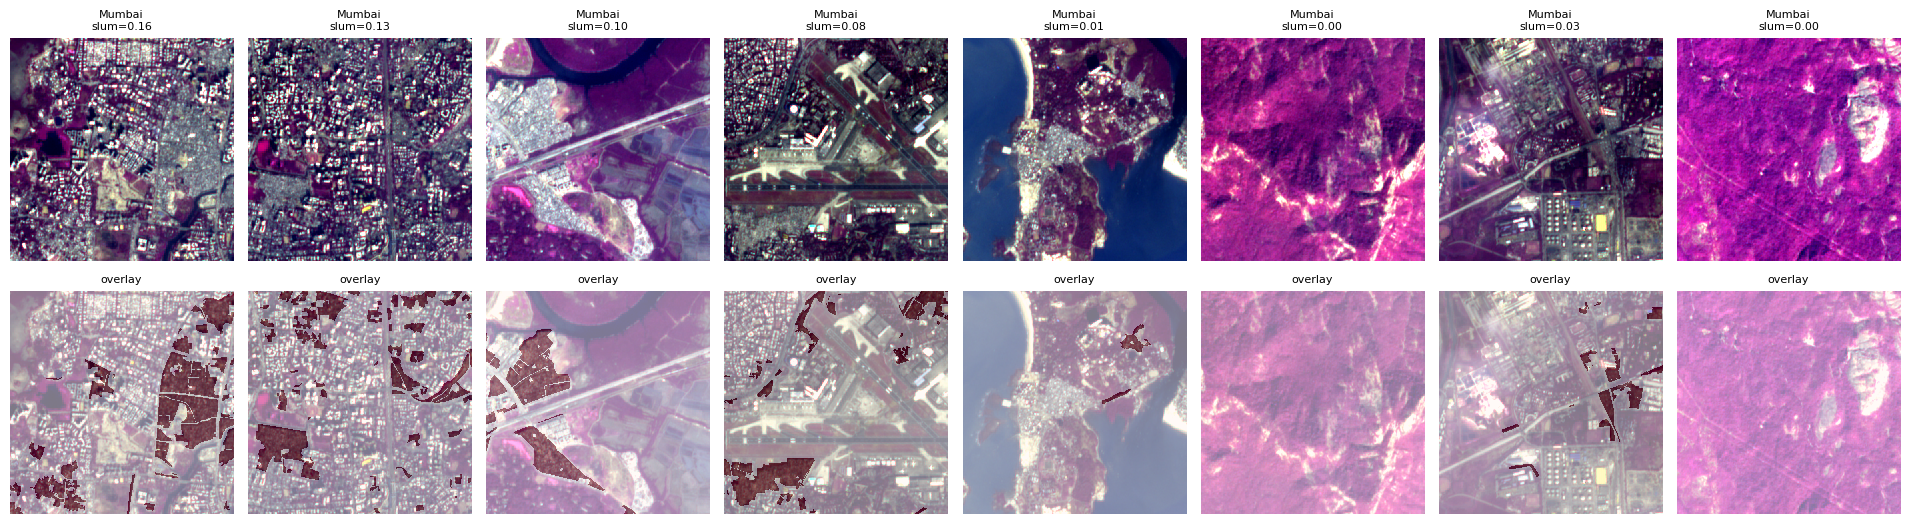


Ditampilkan 8 sample patches (top row: RGB, bottom: overlay).


In [ ]:
# Sample 8 patches: 4 dari yang punya slum, 4 random
np.random.seed(SEED)
has_slum  = manifest[manifest["slum_pixel_ratio"] > 0.05].sample(
    n=min(4, (manifest["slum_pixel_ratio"] > 0.05).sum()), random_state=SEED
)
random_4  = manifest.sample(n=4, random_state=SEED)
sample_df = pd.concat([has_slum, random_4]).head(8).reset_index(drop=True)

n = len(sample_df)
fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.5), squeeze=False)

for i, row in sample_df.iterrows():
    npz = np.load(PROC_DIR / row["image_relpath"])
    img = npz["image"]   
    lbl = npz["label"]  

    # RGB = (RED, GREEN, BLUE) = (idx 2, 1, 0)
    rgb = img[[2, 1, 0]].transpose(1, 2, 0)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

    axes[0, i].imshow(rgb)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"{row['area'][:8]}\nslum={row['slum_pixel_ratio']:.2f}",
                         fontsize=8)

    axes[1, i].imshow(rgb)
    axes[1, i].imshow(lbl, alpha=0.5, cmap="Reds")
    axes[1, i].axis("off")
    axes[1, i].set_title("overlay", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "s14_sample_patches.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"\nDitampilkan {n} sample patches (top row: RGB, bottom: overlay).")

---
## 15. PART A Milestone - Mumbai + Nairobi Selesai

In [ ]:
print("=" * 60)
print("PART A SELESAI - Mumbai + Nairobi")
print("=" * 60)
print(f"Patches FDL terkumpul    : {len(manifest)}")
print(f"Sources                  : {sorted(manifest['source'].unique())}")
print(f"\nDistribusi per source:")
for s, c in manifest['source'].value_counts().items():
    print(f"  {s:>10s}: {c} patches")

# Simpan manifest_partA terpisah untuk safety (kalau Part B gagal,
manifest.to_csv(PROC_DIR / "manifest_partA_fdl.csv", index=False)
print(f"\nBackup manifest Part A: {PROC_DIR / 'manifest_partA_fdl.csv'}")
print(f"\nLanjut ke PART B - Indonesia DKI Jakarta...")

PART A SELESAI - Mumbai + Nairobi
Patches FDL terkumpul    : 547
Sources                  : ['mumbai', 'nairobi']

Distribusi per source:
      mumbai: 544 patches
     nairobi: 3 patches

Backup manifest Part A: E:\competition\Datathon\processed\manifest_partA_fdl.csv

Lanjut ke PART B - Indonesia DKI Jakarta...


---
---

# PART B - Indonesia (DKI Jakarta) Preprocessing

Bagian ini memproses data DKI Jakarta yang formatnya berbeda dari FDL Slums:
- Image: multi-tile `.tif` di `images/slum/` dan `images/non_slum/`.
- Label: GeoJSON polygon vektor (`dki_slum.geojson`, `dki_non_slum.geojson`).

**Tantangan teknis Indonesia:**

1. **GeoJSON -> Raster mask**: polygon vektor harus di-rasterize **per-tile** dengan respect terhadap `transform` dan `CRS` tile (kalau salah, label akan offset = bencana).

2. **CRS mismatch**: GeoJSON DKI biasanya `EPSG:4326` (lat-lon), sedangkan tile Sentinel-2 di-project ke UTM zone 48S (`EPSG:32748`). Polygon harus di-reproject ke CRS tile dulu sebelum rasterize.

3. **Tile non_slum**: secara semantik tile ini berada di area tanpa slum. Mask di-set **all-zero** untuk binary classification (slum vs non-slum).

4. **Spatial filtering polygon**: untuk efisiensi, hanya polygon yang **berpotongan dengan bounding box tile** yang di-rasterize. Mempercepat 10-100x untuk dataset besar.


---
## 16. Indonesia - Inventory Tile


In [ ]:
def inventory_indonesia():
    rows = []
    if not INDONESIA_IMG_SLUM.exists():
        print(f"[indonesia] folder slum tidak ada: {INDONESIA_IMG_SLUM}")
    else:
        for img in sorted(INDONESIA_IMG_SLUM.glob("*.tif")):
            rows.append({
                "source"          : "indonesia",
                "area"            : "slum",
                "image_path"      : str(img),
                "label_path"      : str(INDONESIA_LBL_SLUM),
                "tile_class_hint" : "slum",
                "size_mb"         : img.stat().st_size / 1e6,
                "has_label"       : INDONESIA_LBL_SLUM.exists(),
            })
    if not INDONESIA_IMG_NONSL.exists():
        print(f"[indonesia] folder non_slum tidak ada: {INDONESIA_IMG_NONSL}")
    else:
        for img in sorted(INDONESIA_IMG_NONSL.glob("*.tif")):
            rows.append({
                "source"          : "indonesia",
                "area"            : "non_slum",
                "image_path"      : str(img),
                "label_path"      : str(INDONESIA_LBL_NONSL),
                "tile_class_hint" : "non_slum",
                "size_mb"         : img.stat().st_size / 1e6,
                "has_label"       : True,  
            })
    return pd.DataFrame(rows)


inv_indo = inventory_indonesia()
print(f"=== Indonesia Inventory ===")
print(f"Total tile: {len(inv_indo)}")
if len(inv_indo) > 0:
    print(f"\nDistribusi per hint:")
    print(inv_indo.groupby("tile_class_hint").agg(
        n_tiles=("image_path", "count"),
        size_MB=("size_mb",    "sum")
    ).round(2))
    print(f"\nTotal size : {inv_indo['size_mb'].sum()/1024:.2f} GB")
else:
    raise FileNotFoundError(
        f"Tidak ada tile Indonesia ditemukan di {INDONESIA_IMG_SLUM} atau {INDONESIA_IMG_NONSL}. "
        f"Pastikan struktur folder benar."
    )

=== Indonesia Inventory ===
Total tile: 401

Distribusi per hint:
                 n_tiles  size_MB
tile_class_hint                  
non_slum             261   145.76
slum                 140    15.06

Total size : 0.16 GB


---
## 17. Inspect Indonesia Tile Metadata + GeoJSON


In [17]:
# === Inspect 1 sample tile slum + 1 non_slum ===
print("=== Sample Tile Indonesia ===\n")
for hint in ["slum", "non_slum"]:
    sub = inv_indo[inv_indo["tile_class_hint"] == hint]
    if len(sub) == 0:
        print(f"[{hint}] tidak ada tile, skip\n")
        continue
    sample_img = sub.iloc[0]["image_path"]
    with rasterio.open(sample_img) as src:
        print(f"[{hint}] {Path(sample_img).name}")
        print(f"  Bands  : {src.count}")
        print(f"  Shape  : {src.height} x {src.width}")
        print(f"  Dtype  : {src.dtypes[0]}")
        print(f"  CRS    : {src.crs}")
        print(f"  Bounds : {tuple(round(v,2) for v in src.bounds)}")
        print(f"  Nodata : {src.nodata}")
        print()

# === Inspect GeoJSON ===
print("=== GeoJSON Inspection ===\n")
for label_name, lbl_path in [("slum", INDONESIA_LBL_SLUM), ("non_slum", INDONESIA_LBL_NONSL)]:
    if not lbl_path.exists():
        print(f"[{label_name}] GeoJSON tidak ada: {lbl_path}\n")
        continue
    gdf = gpd.read_file(lbl_path)
    print(f"[{label_name}] {lbl_path.name}")
    print(f"  N polygon : {len(gdf)}")
    print(f"  CRS       : {gdf.crs}")
    print(f"  Geometry  : {gdf.geom_type.value_counts().to_dict()}")
    if len(gdf) > 0:
        bnds = gdf.total_bounds
        print(f"  Total bbox: lon=[{bnds[0]:.4f},{bnds[2]:.4f}], lat=[{bnds[1]:.4f},{bnds[3]:.4f}]")
    print(f"  Columns   : {list(gdf.columns)[:8]}")
    print()

=== Sample Tile Indonesia ===

[slum] SLUM_ANCOL_RW_01_ID86.tif
  Bands  : 6
  Shape  : 173 x 154
  Dtype  : float64
  CRS    : EPSG:4326
  Bounds : (106.81, -6.13, 106.82, -6.11)
  Nodata : 0.0

[non_slum] NONSLUM_ANCOL_UNK_RW_ID1.tif
  Bands  : 6
  Shape  : 524 x 1105
  Dtype  : float64
  CRS    : EPSG:4326
  Bounds : (106.81, -6.14, 106.91, -6.09)
  Nodata : 0.0

=== GeoJSON Inspection ===

[slum] dki_slum.geojson
  N polygon : 140
  CRS       : EPSG:4326
  Geometry  : {'Polygon': 136, 'MultiPolygon': 4}
  Total bbox: lon=[106.7125,106.9691], lat=[-6.3025,-6.0902]
  Columns   : ['FID', 'KAB_NAME', 'KEC_NAME', 'KEL_NAME', 'RW', 'Luas_Ha', 'STATUS', 'SUMBER']

[non_slum] dki_non_slum.geojson
  N polygon : 261
  CRS       : EPSG:4326
  Geometry  : {'Polygon': 259, 'MultiPolygon': 2}
  Total bbox: lon=[106.6856,106.9740], lat=[-6.3726,-6.0892]
  Columns   : ['FID', 'Kecamatan', 'KELURAHAN', 'STATUS', 'CITRA', 'LUAS', 'LONGTITUDE', 'LATITUDE']



**Yang perlu diperhatikan:**

1. **CRS tile vs CRS GeoJSON**: kalau berbeda (tile UTM, GeoJSON WGS84), kita harus reproject GeoJSON -> CRS tile sebelum rasterize. Function `rasterize_polygons_to_tile` di Section 19 menangani ini otomatis.

2. **Bounding box DKI**: GeoJSON DKI Jakarta harus berada di sekitar lon=[106.6, 107.1], lat=[-6.4, -6.0]. Kalau jauh dari range ini, ada masalah dengan file GeoJSON.

3. **Bands Indonesia**: idealnya sudah 6 band Prithvi (BLUE, GREEN, RED, NIR, SWIR1, SWIR2). Kalau 10 atau 13 band, function extraction akan auto-map (sama dengan Mumbai/Nairobi).


---
## 18. Load GeoJSON Polygon

**WHAT:** Load `dki_slum.geojson` sekali ke memory sebagai GeoDataFrame, akan di-reuse untuk setiap tile.

**WHY caching:**
- Loading GeoJSON DKI bisa makan 1-3 detik (banyak polygon).
- Kalau di-load ulang per tile, total time = N_tile x 2s = bisa menit-menit.
- Cache sekali, share ke semua tile.


In [18]:
# Load polygon slum sekali, cache untuk semua tile
gdf_slum_polygons = gpd.read_file(INDONESIA_LBL_SLUM)
print(f"Loaded {len(gdf_slum_polygons)} slum polygons (CRS: {gdf_slum_polygons.crs})")
print(f"Total area covered: {gdf_slum_polygons.to_crs(epsg=3857).area.sum()/1e6:.2f} km^2 (web mercator approx)")

# Drop empty/invalid geometries
n_before = len(gdf_slum_polygons)
gdf_slum_polygons = gdf_slum_polygons[gdf_slum_polygons.geometry.notna()]
gdf_slum_polygons = gdf_slum_polygons[gdf_slum_polygons.geometry.is_valid]
n_after = len(gdf_slum_polygons)
if n_before != n_after:
    print(f"Drop {n_before - n_after} polygon invalid/null. Tersisa: {n_after}")

Loaded 140 slum polygons (CRS: EPSG:4326)
Total area covered: 46.99 km^2 (web mercator approx)


---
## 19. Function: GeoJSON Polygon -> Raster Mask per Tile

**WHAT:** Function `rasterize_polygons_to_tile(image_path, polygons_gdf)` -> binary mask 2D dengan shape sama seperti tile.

**WHY langkah-langkah ini:**

1. **Buka tile** -> dapatkan `transform`, `crs`, `width`, `height`. Ini parameter spatial yang harus dipakai saat rasterize.

2. **Reproject polygon** ke CRS tile kalau berbeda. `gpd.to_crs(crs)` lebih akurat dari `transform_geom` per polygon.

3. **Spatial filter**: hanya polygon yang `intersects` dengan bbox tile yang dipakai. Polygon di luar tile tidak akan kontribusi ke mask, hemat compute.

4. **Rasterize** dengan `rasterio.features.rasterize`:
   - `out_shape = (H, W)` cocok dengan tile.
   - `transform` cocok dengan tile -> 1 polygon pixel = 1 tile pixel.
   - `fill = 0` -> background non-slum.
   - `default_value = 1` -> polygon area jadi class 1 (slum).
   - `dtype = uint8` -> hemat memory.

5. **Tile non_slum**: bypass rasterize, return `np.zeros(...)`. Lebih cepat dan eksplisit.


In [ ]:
def rasterize_polygons_to_tile(image_path, polygons_gdf, hint="slum"):
    """Generate binary mask (H,W) untuk tile dari GeoJSON polygons.

    Args:
        image_path: path tile .tif
        polygons_gdf: GeoDataFrame dgn geometry (polygon area slum)
        hint: "slum" -> rasterize polygons; "non_slum" -> mask all-zero

    Returns:
        np.ndarray uint8 shape (H, W), value 0 atau 1
    """
    with rasterio.open(image_path) as src:
        H, W   = src.height, src.width
        tile_crs = src.crs
        tile_transform = src.transform
        tile_bounds    = src.bounds  

    # Tile non_slum -> mask kosong
    if hint == "non_slum" or polygons_gdf is None or len(polygons_gdf) == 0:
        return np.zeros((H, W), dtype=np.uint8)

    # Reproject polygons ke CRS tile kalau berbeda
    if polygons_gdf.crs != tile_crs:
        gdf = polygons_gdf.to_crs(tile_crs)
    else:
        gdf = polygons_gdf

    # Spatial filter: hanya polygon yg intersect tile bounds
    tile_box = box(tile_bounds.left, tile_bounds.bottom, tile_bounds.right, tile_bounds.top)
    gdf_local = gdf[gdf.geometry.intersects(tile_box)]

    if len(gdf_local) == 0:
        return np.zeros((H, W), dtype=np.uint8)

    # Build (geometry, value) tuples untuk rasterize
    shapes = [(geom, 1) for geom in gdf_local.geometry if geom is not None and geom.is_valid]
    if len(shapes) == 0:
        return np.zeros((H, W), dtype=np.uint8)

    mask = rasterize(
        shapes,
        out_shape  = (H, W),
        transform  = tile_transform,
        fill       = 0,
        all_touched= True,     
        dtype      = np.uint8,
    )
    return mask


# Test cepat: rasterize 1 sample tile slum, lihat % coverage
sample_slum = inv_indo[inv_indo["tile_class_hint"] == "slum"]
if len(sample_slum) > 0:
    test_img = sample_slum.iloc[0]["image_path"]
    test_mask = rasterize_polygons_to_tile(test_img, gdf_slum_polygons, "slum")
    print(f"Test rasterize: {Path(test_img).name}")
    print(f"  Mask shape   : {test_mask.shape}")
    print(f"  Slum coverage: {test_mask.mean()*100:.2f}%")
    print(f"  Slum pixels  : {int(test_mask.sum()):,} dari {test_mask.size:,}")

Test rasterize: SLUM_ANCOL_RW_01_ID86.tif
  Mask shape   : (173, 154)
  Slum coverage: 72.21%
  Slum pixels  : 19,238 dari 26,642


---
## 20. EDA Raw Indonesia - Visual Sample (RGB + Overlay)

**WHAT:** Tampilkan 3 sample tile slum + 3 sample tile non_slum dengan RGB + overlay mask.

**WHY:**
- Validasi visual: mask polygon overlay dengan area built-up dense yang seharusnya = slum.
- Cek kualitas image (apakah ada cloud, awan, missing data).
- Compare visual signature slum DKI vs non-slum.


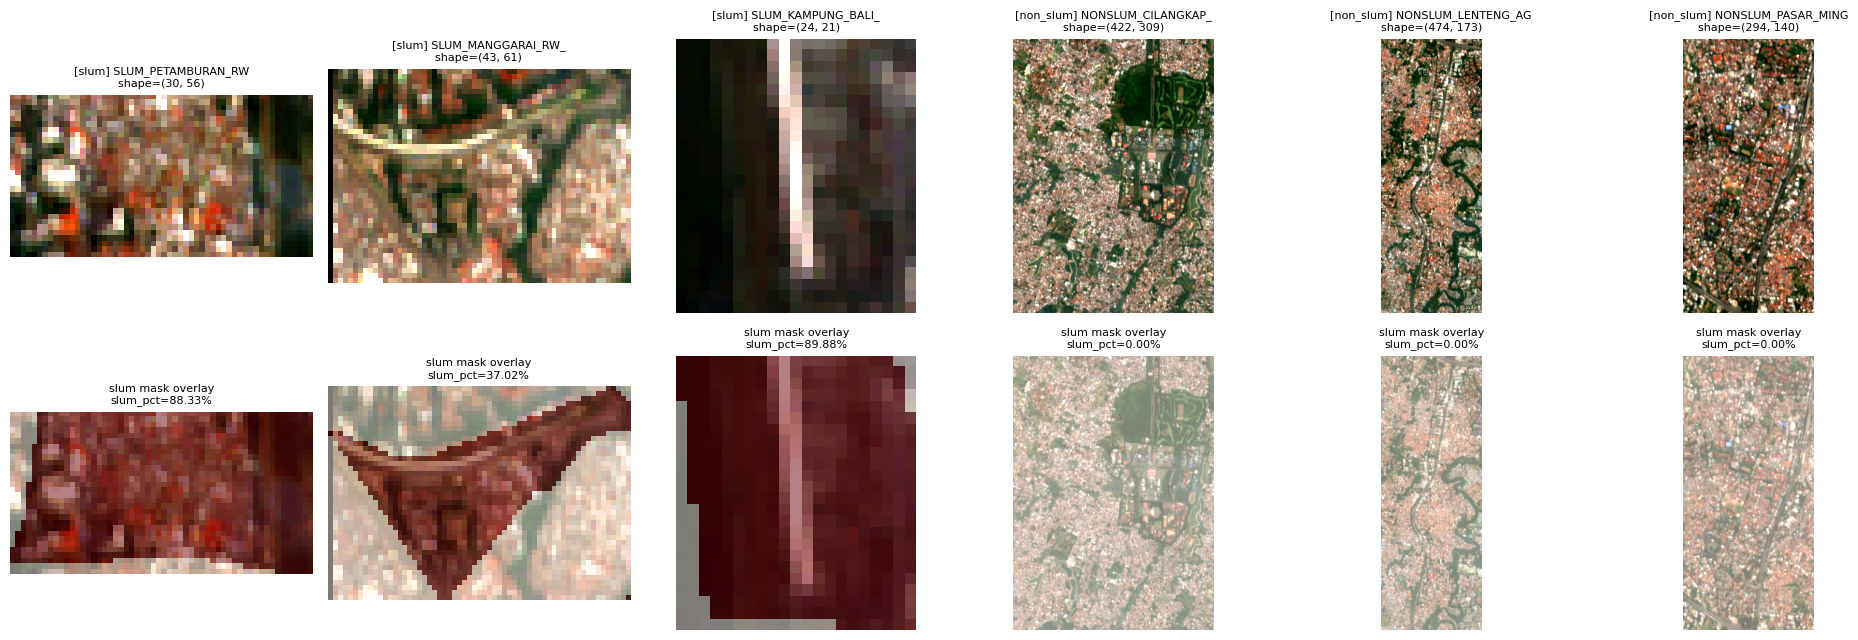


Ditampilkan 6 sample tile Indonesia.


In [20]:
def load_rgb_indonesia(image_path):
    """Load RGB composite Indonesia. Coba 6-band order dulu (RED idx 2), fallback ke 10/13."""
    with rasterio.open(image_path) as src:
        n_bands = src.count
        if n_bands == 6:
            # Order Prithvi: BLUE GREEN RED NIR SWIR1 SWIR2 -> RGB = (3,2,1) rasterio 1-indexed
            rgb = src.read([3, 2, 1]).astype(np.float32)
        elif n_bands == 10:
            # FDL 10-band: B1..B12 -> RGB = (4,3,2)
            rgb = src.read([4, 3, 2]).astype(np.float32)
        elif n_bands == 13:
            # S2 L2A 13-band -> RGB = (4,3,2)
            rgb = src.read([4, 3, 2]).astype(np.float32)
        else:
            rgb = src.read([1, 1, 1]).astype(np.float32)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)
    return rgb.transpose(1, 2, 0)


# Sample 3 tile per hint
np.random.seed(SEED)
samples = []
for hint in ["slum", "non_slum"]:
    sub = inv_indo[inv_indo["tile_class_hint"] == hint]
    if len(sub) == 0:
        continue
    pick = sub.sample(n=min(3, len(sub)), random_state=SEED)
    samples.append(pick)
sample_df = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()

if len(sample_df) > 0:
    n = len(sample_df)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.5), squeeze=False)
    for i, row in sample_df.iterrows():
        rgb  = load_rgb_indonesia(row["image_path"])
        mask = rasterize_polygons_to_tile(
            row["image_path"], gdf_slum_polygons, row["tile_class_hint"]
        )
        slum_pct = mask.mean() * 100

        axes[0, i].imshow(rgb); axes[0, i].axis("off")
        axes[0, i].set_title(
            f"[{row['tile_class_hint']}] {Path(row['image_path']).stem[:18]}\n"
            f"shape={rgb.shape[:2]}", fontsize=8
        )
        axes[1, i].imshow(rgb); axes[1, i].imshow(mask, alpha=0.5, cmap="Reds")
        axes[1, i].axis("off")
        axes[1, i].set_title(f"slum mask overlay\nslum_pct={slum_pct:.2f}%", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "s20_indonesia_raw_samples.png", bbox_inches="tight", dpi=120)
    plt.show()
    print(f"\nDitampilkan {n} sample tile Indonesia.")

**Interpretasi visual:**

- **Tile slum**: harus ada overlay merah (mask) pada area built-up dense (rooftop kecil, jalan sempit). Kalau tidak ada overlay sama sekali, kemungkinan polygon GeoJSON tidak intersect tile -> cek CRS dan koordinat.

- **Tile non_slum**: overlay harus 0% (semua hitam). Kalau ada overlay, ada bug di rasterize function.

- **Kualitas RGB**: bila terlalu putih = cloud cover tinggi (perlu filter), bila terlalu hijau = vegetasi dominan (kemungkinan area pinggiran).


---
## 21. Indonesia Patch Extraction 


In [ ]:
def extract_patches_indonesia(image_path, polygons_gdf, hint, source="indonesia",
                                   patch_size=PATCH_SIZE, stride=STRIDE):
    """Extract patches Indonesia, rasterize mask on-the-fly per tile."""
    # Read image bands sekali
    with rasterio.open(image_path) as src_img:
        n_bands_in = src_img.count
        if n_bands_in == 6:
            band_idx_local = [0, 1, 2, 3, 4, 5]
        elif n_bands_in == 10:
            band_idx_local = [1, 2, 3, 7, 8, 9]   
        elif n_bands_in == 13:
            band_idx_local = [1, 2, 3, 7, 11, 12] 
        else:
            raise ValueError(f"Tile {image_path} punya {n_bands_in} band, tidak dikenal")
        rio_indexes = [b + 1 for b in band_idx_local]
        img = src_img.read(rio_indexes).astype(np.float32)  

    # Generate mask (rasterize jika slum, all-zero jika non_slum)
    mask = rasterize_polygons_to_tile(image_path, polygons_gdf, hint)

    # Crop kalau shape sedikit beda
    H_img, W_img = img.shape[1], img.shape[2]
    H_lbl, W_lbl = mask.shape
    H, W = min(H_img, H_lbl), min(W_img, W_lbl)
    img  = img[:, :H, :W]
    mask = mask[:H, :W]

    # Adaptive: tile Indonesia juga bisa kecil, terapkan strategi sama
    img, mask, mode = adapt_to_min_size(img, mask, patch_size=patch_size,
                                         min_for_pad=MIN_FOR_PAD)
    H, W = img.shape[1], img.shape[2]

    tile_stem = Path(image_path).stem
    patches_info = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            img_patch  = img[:, y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            # Quality filters (sama dengan Mumbai/Nairobi)
            zero_frac = float((img_patch == 0).all(axis=0).mean())
            if zero_frac > NODATA_FRAC_MAX:
                continue
            if not np.isfinite(img_patch).all():
                continue
            if img_patch.std() < STD_MIN:
                continue

            slum_ratio = float(mask_patch.mean())

            patch_id   = f"{source}__{hint}__{tile_stem}__y{y}_x{x}"
            patch_file = PATCHES_DIR / f"{patch_id}.npz"
            np.savez_compressed(
                patch_file,
                image=img_patch.astype(np.float32),
                label=mask_patch.astype(np.uint8)
            )

            patches_info.append({
                "patch_id"        : patch_id,
                "source"          : source,
                "area"            : hint,           
                "image_relpath"   : f"patches/{patch_id}.npz",
                "label_relpath"   : f"patches/{patch_id}.npz",
                "extraction_mode" : mode,
                "x_coord"         : int(x),
                "y_coord"         : int(y),
                "slum_pixel_ratio": round(slum_ratio, 6),
            })
    return patches_info


# === Run extraction loop ===
all_indo_patches = []
for _, row in tqdm(inv_indo.iterrows(), total=len(inv_indo), desc="Indonesia tiles"):
    p_info = extract_patches_indonesia(
        row["image_path"], gdf_slum_polygons,
        hint=row["tile_class_hint"]
    )
    all_indo_patches.extend(p_info)
    print(f"  [{row['tile_class_hint']:>8s}] {Path(row['image_path']).stem[:30]:>30s}  -> {len(p_info)} patches")

manifest_indo = pd.DataFrame(all_indo_patches)
print(f"\n=== Indonesia Extraction Selesai ===")
print(f"Total patches Indonesia: {len(manifest_indo)}")
if len(manifest_indo) > 0:
    print(f"\nDistribusi per hint area:")
    print(manifest_indo.groupby("area").agg(
        n_patches      =("patch_id", "count"),
        mean_slum_ratio=("slum_pixel_ratio", "mean"),
        n_pure_nonslum =("slum_pixel_ratio", lambda x: (x == 0).sum()),
        n_has_slum     =("slum_pixel_ratio", lambda x: (x > 0).sum()),
    ).round(3))

Indonesia tiles:   1%|          | 4/401 [00:00<00:20, 18.91it/s]

  [    slum]          SLUM_ANCOL_RW_01_ID86  -> 1 patches
  [    slum]          SLUM_ANCOL_RW_02_ID87  -> 1 patches
  [    slum]          SLUM_ANCOL_RW_04_ID88  -> 1 patches
  [    slum]          SLUM_ANCOL_RW_05_ID89  -> 1 patches
  [    slum]          SLUM_ANCOL_RW_08_ID90  -> 1 patches


Indonesia tiles:   2%|▏         | 8/401 [00:00<00:51,  7.66it/s]

  [    slum]          SLUM_ANCOL_RW_10_ID91  -> 12 patches
  [    slum] SLUM_BENDUNGAN_HILIR_RW_07_ID3  -> 1 patches
  [    slum]    SLUM_BUKIT_DURI_RW_11_ID133  -> 1 patches


Indonesia tiles:   3%|▎         | 12/401 [00:01<00:38, 10.22it/s]

...

  [non_slum] NONSLUM_TEGAL_ALUR_UNK_RW_ID24  -> 2 patches
  [non_slum] NONSLUM_TEGAL_PARANG_UNK_RW_ID  -> 1 patches
  [non_slum]    NONSLUM_TOMANG_UNK_RW_ID247  -> 1 patches
  [non_slum] NONSLUM_TUGU_SELATAN_UNK_RW_ID  -> 1 patches
  [non_slum] NONSLUM_TUGU_UTARA_UNK_RW_ID24  -> 1 patches


Indonesia tiles:  99%|█████████▉| 396/401 [00:26<00:00, 16.19it/s]

  [non_slum] NONSLUM_UJUNG_MENTENG_UNK_RW_I  -> 1 patches
  [non_slum]   NONSLUM_ULUJAMI_UNK_RW_ID251  -> 1 patches
  [non_slum] NONSLUM_UTAN_KAYU_SELATAN_UNK_  -> 1 patches
  [non_slum] NONSLUM_UTAN_KAYU_UTARA_UNK_RW  -> 1 patches
  [non_slum] NONSLUM_UTAN_PANJANG_UNK_RW_ID  -> 1 patches


Indonesia tiles: 100%|██████████| 401/401 [00:27<00:00, 14.75it/s]

  [non_slum]   NONSLUM_WARAKAS_UNK_RW_ID255  -> 1 patches
  [non_slum] NONSLUM_WIJAYA_KESUMA_UNK_RW_I  -> 1 patches

=== Indonesia Extraction Selesai ===
Total patches Indonesia: 523

Distribusi per hint area:
          n_patches  mean_slum_ratio  n_pure_nonslum  n_has_slum
area                                                            
non_slum        371            0.000             371           0
slum            152            0.659               1         151


---
## 22. Merge Manifest All Sources + EDA Indonesia


In [22]:
# === Merge & save ===
manifest_full = pd.concat([manifest, manifest_indo], ignore_index=True)
manifest_full.to_csv(PROC_DIR / "manifest.csv", index=False)

print(f"=== Manifest Final ===")
print(f"Total patches: {len(manifest_full)}")
print(f"\nDistribusi per source:")
print(manifest_full["source"].value_counts())
print(f"\nDistribusi per (source, area):")
print(manifest_full.groupby(["source","area"]).size().to_frame("n_patches"))
print(f"\nSaved: {PROC_DIR / 'manifest.csv'}")

=== Manifest Final ===
Total patches: 1070

Distribusi per source:
source
mumbai       544
indonesia    523
nairobi        3
Name: count, dtype: int64

Distribusi per (source, area):
                    n_patches
source    area               
indonesia non_slum        371
          slum            152
mumbai    Mumbai          544
nairobi   Kianda            1
          Kibera            1
          Lower             1

Saved: E:\competition\Datathon\processed\manifest.csv


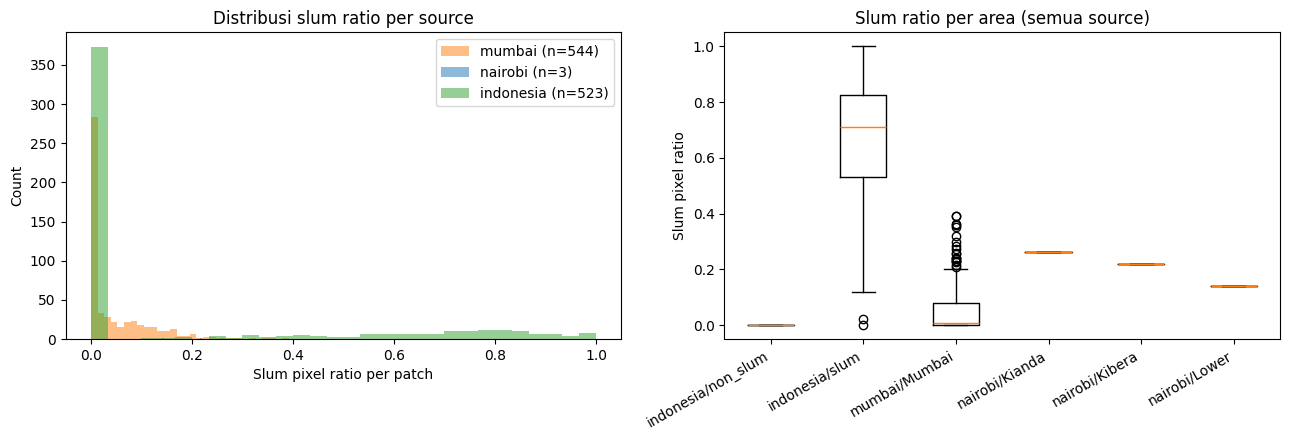


=== Class Balance Indonesia ===
N patches      : 523
Total pixels   : 26,242,048
Slum pixels    : 5,024,408  (19.15%)
Non-slum px    : 21,217,639
Imbalance ratio: 1:4.2


In [23]:
# === EDA: distribusi slum ratio Indonesia vs FDL ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram per source
for src, color in [("mumbai", "#ff7f0e"), ("nairobi", "#1f77b4"), ("indonesia", "#2ca02c")]:
    sub = manifest_full[manifest_full["source"] == src]["slum_pixel_ratio"]
    if len(sub) > 0:
        axes[0].hist(sub, bins=30, alpha=0.5, label=f"{src} (n={len(sub)})", color=color)
axes[0].set_xlabel("Slum pixel ratio per patch")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribusi slum ratio per source")
axes[0].legend()

# Right: boxplot per source/area
sa = manifest_full["source"] + "/" + manifest_full["area"]
keys = sorted(sa.unique())
data = [manifest_full.loc[sa == k, "slum_pixel_ratio"].values for k in keys]
axes[1].boxplot(data, tick_labels=keys)
axes[1].set_xticklabels(keys, rotation=30, ha="right")
axes[1].set_ylabel("Slum pixel ratio")
axes[1].set_title("Slum ratio per area (semua source)")

plt.tight_layout()
plt.savefig(FIG_DIR / "s22_all_sources_slum_dist.png", bbox_inches="tight", dpi=120)
plt.show()

# Summary class balance Indonesia
indo = manifest_full[manifest_full["source"] == "indonesia"]
total_px      = len(indo) * PATCH_SIZE * PATCH_SIZE
slum_px_total = (indo["slum_pixel_ratio"] * PATCH_SIZE * PATCH_SIZE).sum()
print(f"\n=== Class Balance Indonesia ===")
print(f"N patches      : {len(indo)}")
print(f"Total pixels   : {total_px:,}")
print(f"Slum pixels    : {int(slum_px_total):,}  ({slum_px_total/total_px*100:.2f}%)")
print(f"Non-slum px    : {int(total_px - slum_px_total):,}")
print(f"Imbalance ratio: 1:{(total_px - slum_px_total)/max(slum_px_total,1):.1f}")

---
## 23. EDA Indonesia - Sample Patches Visualization

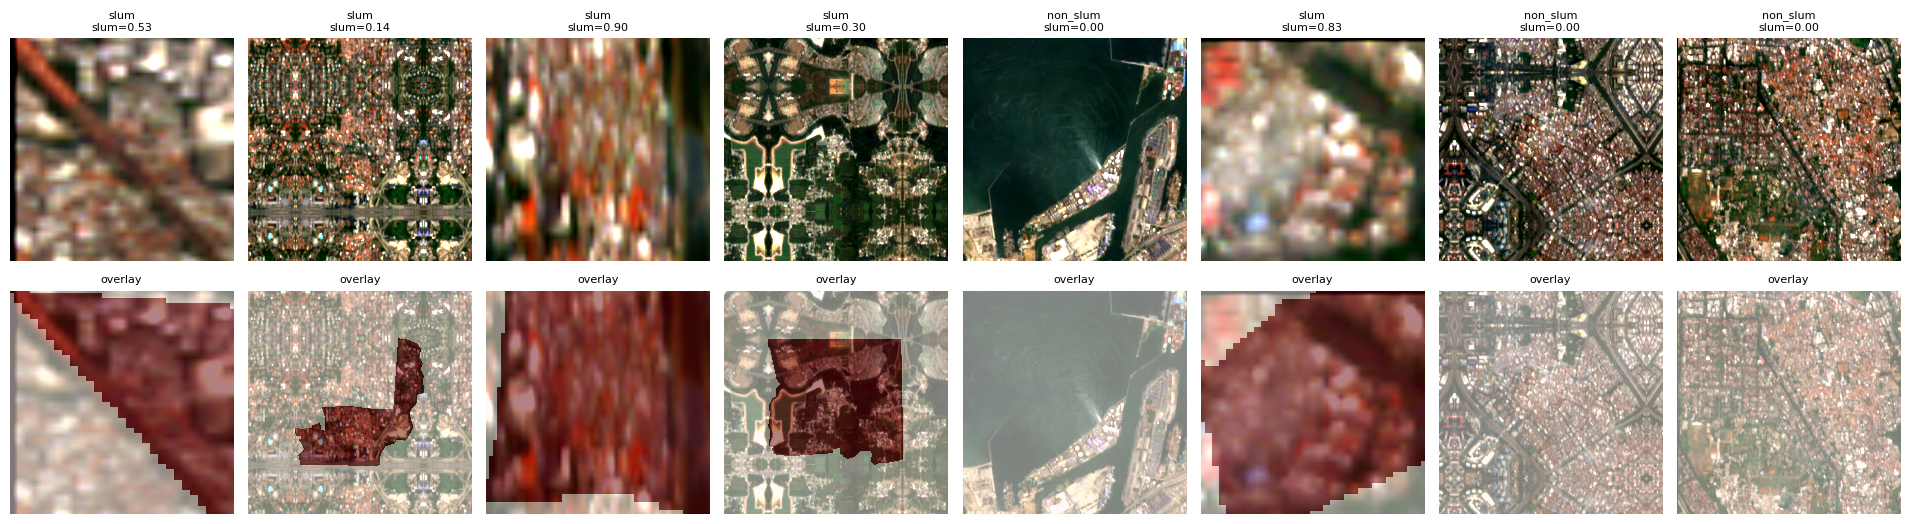


Ditampilkan 8 sample patches Indonesia.


In [24]:
indo = manifest_full[manifest_full["source"] == "indonesia"]
if len(indo) == 0:
    print("Indonesia tidak ada patches, skip")
else:
    np.random.seed(SEED)
    has_slum = indo[indo["slum_pixel_ratio"] > 0.05].sample(
        n=min(4, (indo["slum_pixel_ratio"] > 0.05).sum()), random_state=SEED
    ) if (indo["slum_pixel_ratio"] > 0.05).sum() > 0 else pd.DataFrame()
    random_4 = indo.sample(n=min(4, len(indo)), random_state=SEED+1)
    sample_indo = pd.concat([has_slum, random_4]).head(8).reset_index(drop=True)

    n = len(sample_indo)
    fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.5), squeeze=False)
    for i, row in sample_indo.iterrows():
        npz = np.load(PROC_DIR / row["image_relpath"])
        img = npz["image"]; lbl = npz["label"]
        rgb = img[[2, 1, 0]].transpose(1, 2, 0)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

        axes[0, i].imshow(rgb); axes[0, i].axis("off")
        axes[0, i].set_title(f"{row['area'][:8]}\nslum={row['slum_pixel_ratio']:.2f}", fontsize=8)
        axes[1, i].imshow(rgb); axes[1, i].imshow(lbl, alpha=0.5, cmap="Reds")
        axes[1, i].axis("off")
        axes[1, i].set_title("overlay", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "s23_indonesia_sample_patches.png", bbox_inches="tight", dpi=120)
    plt.show()
    print(f"\nDitampilkan {n} sample patches Indonesia.")

---
---

# PART C - Unified Statistics + Final Summary

Compute statistik per-source untuk **semua source** (mumbai + nairobi + indonesia), simpan ke `stats.json` final.


---
## 24. Compute Stats Per-Source


In [25]:
print("Re-compute statistik per-source (termasuk Indonesia)...\n")
stats_dict_full = {}

for source, grp in manifest_full.groupby("source"):
    accum_sum = np.zeros(6, dtype=np.float64)
    accum_sq  = np.zeros(6, dtype=np.float64)
    accum_n   = 0
    for _, r in tqdm(grp.iterrows(), total=len(grp), desc=f"  [{source}]"):
        npz = np.load(PROC_DIR / r["image_relpath"])
        arr = npz["image"].astype(np.float64)
        accum_sum += arr.sum(axis=(1, 2))
        accum_sq  += (arr ** 2).sum(axis=(1, 2))
        accum_n   += arr.shape[1] * arr.shape[2]

    mean = accum_sum / accum_n
    var  = accum_sq / accum_n - mean ** 2
    std  = np.sqrt(np.clip(var, 1e-12, None))
    stats_dict_full[source] = {
        "mean"      : mean.tolist(),
        "std"       : std.tolist(),
        "band_names": PRITHVI_BAND_NAMES,
        "n_pixels"  : int(accum_n),
        "n_patches" : int(len(grp)),
    }
    print(f"\n[{source}] (n_patches={len(grp)})")
    for i, b in enumerate(PRITHVI_BAND_NAMES):
        print(f"  {b:>6s}: mean={mean[i]:>12.2f}  std={std[i]:>12.2f}")

with open(PROC_DIR / "stats.json", "w") as f:
    json.dump(stats_dict_full, f, indent=2)

print(f"\nStats final disimpan: {PROC_DIR / 'stats.json'}")

Re-compute statistik per-source (termasuk Indonesia)...



  [indonesia]: 100%|██████████| 523/523 [00:14<00:00, 35.58it/s]



[indonesia] (n_patches=523)
    BLUE: mean=        0.10  std=        0.04
   GREEN: mean=        0.11  std=        0.04
     RED: mean=        0.12  std=        0.05
     NIR: mean=        0.20  std=        0.06
   SWIR1: mean=        0.22  std=        0.07
   SWIR2: mean=        0.20  std=        0.08


  [mumbai]: 100%|██████████| 544/544 [00:02<00:00, 221.42it/s]



[mumbai] (n_patches=544)
    BLUE: mean=     1065.65  std=      193.04
   GREEN: mean=      875.31  std=      281.80
     RED: mean=      921.50  std=      254.47
     NIR: mean=     1478.73  std=      807.61
   SWIR1: mean=      982.80  std=      659.44
   SWIR2: mean=      657.35  std=      523.82


  [nairobi]: 100%|██████████| 3/3 [00:00<00:00, 146.26it/s]


[nairobi] (n_patches=3)
    BLUE: mean=     1162.70  std=      239.53
   GREEN: mean=     1274.91  std=      313.83
     RED: mean=     1412.87  std=      224.05
     NIR: mean=     2106.16  std=      387.55
   SWIR1: mean=     2218.75  std=      326.66
   SWIR2: mean=     1844.56  std=      437.82

Stats final disimpan: E:\competition\Datathon\processed\stats.json


**Domain gap analysis:**

Bandingkan mean per band antara FDL (Mumbai/Nairobi) vs Indonesia. Jika perbedaan **>2x lipat**, ada domain shift signifikan -> argumen kuat untuk:
1. Per-source normalization (sudah dilakukan).
2. Phase 2 fine-tuning agresif di decoder (Phase 2 LR sudah di-tune untuk ini).
3. Dataset adapter / domain adaptation kalau perbedaan terlalu besar.

Indonesia biasanya menyimpan reflectance dalam **scale berbeda** dari FDL (FDL kadang 0..10000 DN, Indonesia kadang 0..1 surface reflectance). Perbedaan mean 100-10000x lipat itu **normal** - per-source normalization mengatasinya.


---
## 25. Final Summary + Handoff ke Phase 1 dan Phase 2


In [26]:
print("=" * 65)
print("PREPROCESSING SELESAI - ALL SOURCES")
print("=" * 65)

# Output files
print(f"\nOutput files di {PROC_DIR}:")
files_check = [
    ("manifest.csv",          PROC_DIR / "manifest.csv"),
    ("stats.json",            PROC_DIR / "stats.json"),
    ("manifest_partA_fdl.csv",PROC_DIR / "manifest_partA_fdl.csv"),
]
for name, fp in files_check:
    if fp.exists():
        print(f"  {name:<28s} {fp.stat().st_size/1e3:>10.1f} KB")
    else:
        print(f"  {name:<28s} [MISSING]")

n_npz       = len(list(PATCHES_DIR.glob('*.npz')))
size_npz_mb = sum(f.stat().st_size for f in PATCHES_DIR.glob('*.npz')) / 1e6
print(f"  patches/                    {n_npz} files, {size_npz_mb:.1f} MB")

n_fig = len(list(FIG_DIR.glob('*.png')))
print(f"  figures/                    {n_fig} files")

# Dataset summary
print(f"\nDataset summary:")
print(f"  Total patches  : {len(manifest_full)}")
print(f"  Sources        : {sorted(manifest_full['source'].unique())}")
print(f"\n  Per source:")
for s, c in manifest_full['source'].value_counts().items():
    print(f"    {s:>10s}: {c} patches")

print(f"\n  Per (source, area):")
for (s, a), c in manifest_full.groupby(["source","area"]).size().items():
    print(f"    {s:>10s} / {a:>10s}: {c} patches")

# Class balance per source
print(f"\nClass balance (slum pixel ratio mean):")
for s, grp in manifest_full.groupby("source"):
    print(f"  {s:>10s}: mean slum ratio = {grp['slum_pixel_ratio'].mean():.4f}  "
          f"({(grp['slum_pixel_ratio'] > 0).sum()}/{len(grp)} patches mengandung slum)")

print(f"\n{'='*65}")
print(f"NEXT STEP")
print(f"{'='*65}")
print(f"PHASE 1 -> buka 'slum_phase1_mumbai_nairobi.ipynb'")
print(f"  Skip cell preprocessing inline, lanjut Section 14 (Load Manifest).")
print(f"  Phase 1 akan filter manifest ke source in [mumbai, nairobi].")
print(f"")
print(f"PHASE 2 -> buka 'slum_phase2_indonesia.ipynb'")
print(f"  Skip cell preprocessing inline, lanjut Section 10 (Load Manifest Indonesia).")
print(f"  Phase 2 akan filter manifest ke source == indonesia.")

PREPROCESSING SELESAI - ALL SOURCES

Output files di E:\competition\Datathon\processed:
  manifest.csv                      201.1 KB
  stats.json                          1.7 KB
  manifest_partA_fdl.csv             78.8 KB
  patches/                    1070 files, 411.0 MB
  figures/                    7 files

Dataset summary:
  Total patches  : 1070
  Sources        : ['indonesia', 'mumbai', 'nairobi']

  Per source:
        mumbai: 544 patches
     indonesia: 523 patches
       nairobi: 3 patches

  Per (source, area):
     indonesia /   non_slum: 371 patches
     indonesia /       slum: 152 patches
        mumbai /     Mumbai: 544 patches
       nairobi /     Kianda: 1 patches
       nairobi /     Kibera: 1 patches
       nairobi /      Lower: 1 patches

Class balance (slum pixel ratio mean):
   indonesia: mean slum ratio = 0.1915  (151/523 patches mengandung slum)
      mumbai: mean slum ratio = 0.0479  (341/544 patches mengandung slum)
     nairobi: mean slum ratio = 0.2068  (3/3